# Healthcare ML Platform
## Notebook 06 — Regression: Medical Insurance Cost Prediction

**Dataset:** Medical Insurance Cost (1,337 records)  
**Target:** `charges` — annual insurance cost in USD  
**Input:** `Dataset/processed/insurance_train.csv`  

### What this notebook does
1. Load engineered train/test data
2. Train 6 regression algorithms
3. Evaluate each with RMSE, MAE, R²
4. Compare on a leaderboard
5. Analyse best model — feature importance + residuals
6. Save best model

### Algorithms compared
| Algorithm | Type | Why included |
|---|---|---|
| Linear Regression | Linear baseline | Simplest — sets the floor |
| Ridge | Regularized linear | Handles multicollinearity |
| Lasso | Sparse linear | Auto feature selection |
| ElasticNet | Ridge + Lasso combined | Best of both |
| Random Forest | Tree ensemble | Non-linear, robust |
| XGBoost | Gradient boosted trees | Expected winner |

### Expected outcome
XGBoost should win significantly because of the  
smoker × BMI non-linear interaction.  
Linear models get help from the `smoker_bmi`  
interaction feature we engineered.

In [2]:
from operator import imod

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error,
                            mean_absolute_error,r2_score)
import joblib 
import os
import warnings

warnings.filterwarnings("ignore")

---
## Load Train and Test Data

We load the files saved by the feature engineering notebook.  
Already encoded, scaled, and split.  
Two target columns are available:
- `charges` — original USD scale (for tree models)
- `log_charges` — log transformed (for linear models)

In [3]:
train = pd.read_csv('G:\healthcare\Dataset\processed\insurance_train.csv')
test = pd.read_csv("G:\healthcare\Dataset\processed\insurance_test.csv")

print(f"Train : {train.shape}")
print(f"Test : {test.shape}")

feature_cols = [c for c in train.columns if c not in ["charges","log_charges"]]

X_train = train[feature_cols]
X_test  = test[feature_cols]


  # Two target versions
y_train     = train["charges"]       # original — tree models
y_test      = test["charges"]        # original — evaluation        


y_train_log = train["log_charges"]   # log — linear models
y_test_log  = test["log_charges"]    # log — linear evaluation


print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget ranges:")
print(f"  charges     : ${y_train.min():.0f} — ${y_train.max():.0f}")
print(f"  log_charges : {y_train_log.min():.3f} — {y_train_log.max():.3f}")


Train : (1069, 12)
Test : (268, 12)

Features (10): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi', 'age_sqrd']

Target ranges:
  charges     : $1122 — $62593
  log_charges : 7.024 — 11.044


---
##  Define Evaluation Function

One function handles all models.  
For linear models we pass log-transformed targets  
and inverse-transform predictions back to USD  
so all models are compared on the same scale.

**Why inverse transform?**  
RMSE on log scale is meaningless to a human.  
We want to say "the model is off by $2,400 on average"  
not "the model is off by 0.18 log units".

In [4]:
try:
    del evaluate_model
except:
    pass

def evaluate_model(name, model, X_train, y_train,
                   X_test, y_test, log_target=False):
    """
    Train and evaluate a regression model.
    log_target=True: model trains on log(charges),
                     predictions inverse-transformed for metrics
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Inverse transform if log target was used
    if log_target:
        y_pred    = np.expm1(y_pred)
        y_test_ev = np.expm1(y_test)  # ← inverse transform test too
    else:
        y_test_ev = y_test

    # ALL three metrics use y_test_ev — the inverse transformed version
    rmse = np.sqrt(mean_squared_error(y_test_ev, y_pred))  # ← fixed
    mae  = mean_absolute_error(y_test_ev, y_pred)
    r2   = r2_score(y_test_ev, y_pred)

    print(f"\n{'='*47}")
    print(f"  {name}")
    print(f"{'='*47}")
    print(f"  RMSE : ${rmse:,.2f}  (avg prediction error in USD)")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  R²   : {r2:.4f}")

    return {
        "Model"     : name,
        "RMSE ($)"  : round(rmse, 2),
        "MAE ($)"   : round(mae, 2),
        "R2"        : round(r2, 4),
        "model"     : model,
        "log_target": log_target
    }


---
## Train All 6 Models

Linear models use log-transformed target.  
Tree models use original charges.  
All metrics reported in original USD scale.

In [5]:

results = []

#liner model
results.append(evaluate_model(
    "LinearRegression",
    LinearRegression(),
    X_train,y_train_log,
    X_test,y_test_log,
    log_target=True
))

# Ridge
results.append(evaluate_model(
    "Ridge",
    Ridge(alpha=10.0),
    X_train,y_train_log,
    X_test,y_test_log,
    log_target=True
))

# Lasso
results.append(evaluate_model(
    "Lasso",
    Lasso(alpha=0.001),
    X_train,y_train_log,
    X_test,y_test_log,
    log_target=True
))

# ElasticNet
results.append(evaluate_model(
    "ElasticNet",
    ElasticNet(alpha=0.001,l1_ratio=0.5),
    X_train,y_train_log,
    X_test,y_test_log,
    log_target=True
))

#Random Forest
results.append(evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=1
    ),
    X_train,y_train,
    X_test,y_test,
    log_target=False
))

#XGBoost

results.append(evaluate_model(
    "XGBoost",
    XGBRegressor(
        n_estimators = 300,
        learning_rate = 0.05,
        max_depth =6,
        subsample = 0.8,
        colsample_bytree = 0.8,
        random_state= 42
    ),
    X_train,y_train,
    X_test,y_test,
    log_target=False
))


  LinearRegression
  RMSE : $8,677.89  (avg prediction error in USD)
  MAE  : $4,241.56
  R²   : 0.5902

  Ridge
  RMSE : $7,898.95  (avg prediction error in USD)
  MAE  : $3,971.55
  R²   : 0.6605

  Lasso
  RMSE : $8,623.09  (avg prediction error in USD)
  MAE  : $4,190.89
  R²   : 0.5953

  ElasticNet
  RMSE : $8,577.14  (avg prediction error in USD)
  MAE  : $4,190.88
  R²   : 0.5996

  Random Forest
  RMSE : $4,400.98  (avg prediction error in USD)
  MAE  : $2,458.82
  R²   : 0.8946

  XGBoost
  RMSE : $4,725.33  (avg prediction error in USD)
  MAE  : $2,638.39
  R²   : 0.8785


---
## Model Leaderboard

In [10]:
# Build leaderboard
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["model","log_target"]}
    for r in results
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("Model Leaderboard (sorted by R2):\n")
print(results_df.to_string(index=False))

Model Leaderboard (sorted by R2):

           Model  RMSE ($)  MAE ($)     R2
   Random Forest   4400.98  2458.82 0.8946
         XGBoost   4725.33  2638.39 0.8785
           Ridge   7898.95  3971.55 0.6605
      ElasticNet   8577.14  4190.88 0.5996
           Lasso   8623.09  4190.89 0.5953
LinearRegression   8677.89  4241.56 0.5902


---
## Best Model Analysis

We analyse the best model in detail:
1. Actual vs predicted scatter plot
2. Residual distribution
3. Feature importance
4. Error analysis — where does the model struggle most?

Best model : Random Forest
R²         : 0.8946
RMSE       : $4,400.98


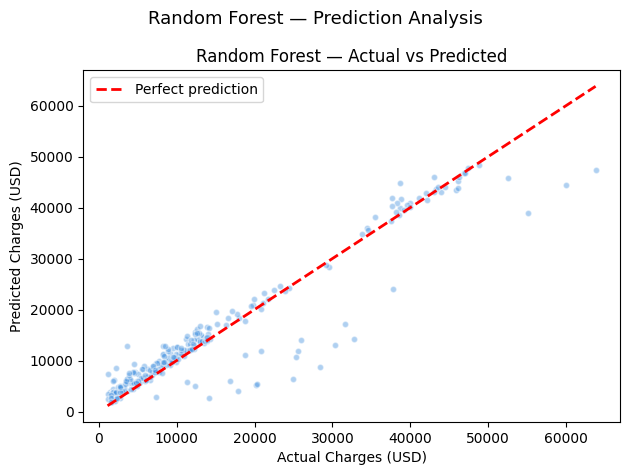

In [19]:
# Get best model by R²
best = max(results, key=lambda x: x["R2"])
best_model = best["model"]
print(f"Best model : {best['Model']}")
print(f"R²         : {best['R2']}")
print(f"RMSE       : ${best['RMSE ($)']:,.2f}")

# Predictions on test set
y_pred = best_model.predict(X_test)


# Actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.4,
                color="#378ADD", s=20, edgecolors="white")
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--",
             linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Charges (USD)")
plt.ylabel("Predicted Charges (USD)")
plt.title(f"{best['Model']} — Actual vs Predicted")
plt.legend()


plt.suptitle(f"{best['Model']} — Prediction Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("G:/healthcare/outputs/insurance_best_model.png", dpi=150)
plt.show()

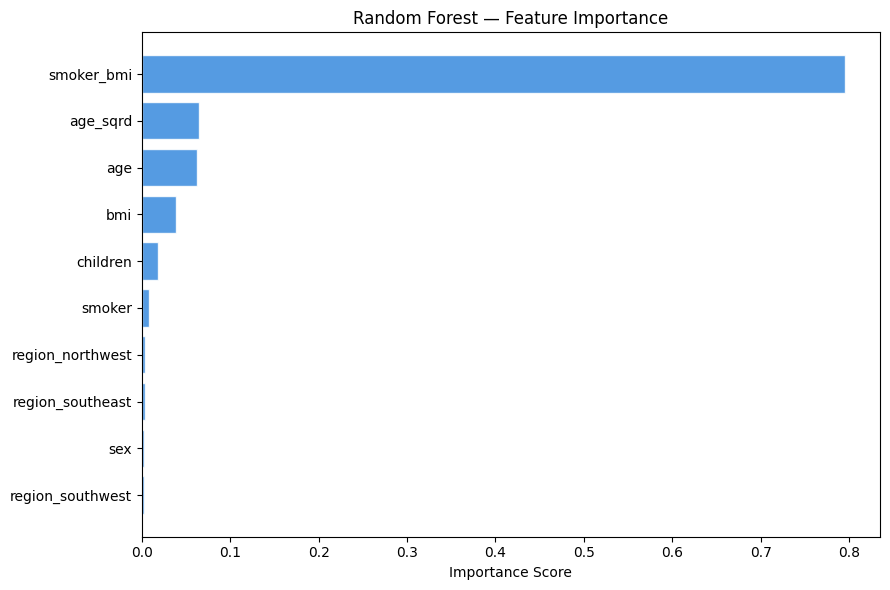

Top 5 most important features:
  smoker_bmi           0.7953
  age_sqrd             0.0646
  age                  0.0629
  bmi                  0.0387
  children             0.0182


In [20]:
# Feature importance — works for XGBoost and Random Forest
if hasattr(best_model, "feature_importances_"):
    importances  = best_model.feature_importances_
    indices      = np.argsort(importances)

    plt.figure(figsize=(9, 6))
    plt.barh(
        [feature_cols[i] for i in indices],
        importances[indices],
        color="#378ADD", edgecolor="white", alpha=0.85
    )
    plt.xlabel("Importance Score")
    plt.title(f"{best['Model']} — Feature Importance")
    plt.tight_layout()
    plt.savefig("G:/healthcare/outputs/insurance_feature_importance.png",
                dpi=150)
    plt.show()

    print("Top 5 most important features:")
    top5 = sorted(zip(feature_cols, importances),
                  key=lambda x: x[1], reverse=True)[:5]
    for feat, imp in top5:
        print(f"  {feat:<20} {imp:.4f}")
else:
    # For linear models — use coefficients
    coefs = pd.Series(best_model.coef_, index=feature_cols)
    coefs.abs().sort_values().plot(kind="barh", color="#378ADD",
                                   edgecolor="white", figsize=(9,6))
    plt.title(f"{best['Model']} — Feature Coefficients (absolute)")
    plt.tight_layout()
    plt.show()

In [24]:
os.makedirs("G:/healthcare/models", exist_ok=True)

joblib.dump(best_model, "G:/healthcare/models/regression_insurance.pkl")

print(f"Best model saved: models/regression_insurance.pkl")
print(f"\nFinal Results:")
print(f"  Model : {best['Model']}")
print(f"  R2    : {best['R2']}")
print(f"  RMSE  : ${best['RMSE ($)']:,.2f}")
print(f"  MAE   : ${best['MAE ($)']:,.2f}")
print(f"\nModels folder:")
for f in sorted(os.listdir("G:/healthcare/models")):
    print(f"  - {f}")

Best model saved: models/regression_insurance.pkl

Final Results:
  Model : Random Forest
  R2    : 0.8946
  RMSE  : $4,400.98
  MAE   : $2,458.82

Models folder:
  - insurance_scaler.pkl
  - knn_recommender.pkl
  - recommendation_scaler.pkl
  - regression_insurance.pkl


---
## Regression Summary — Insurance Cost

### Results

| Model | RMSE ($) | MAE ($)    | R2|
|------|---|---|---|
|Random Forest |  4400.98 | 2458.82 |0.8946|
|XGBoost |  4725.33 | 2638.39 |0.8785|
|  Ridge |  7898.95 | 3971.55 |0.6605|
| ElasticNet |  8577.14 | 4190.88 |0.5996|
|  Lasso |  8623.09 | 4190.89 |0.5953|
|LinearRegression  | 8677.89 | 4241.56| 0.5902|

### Key insights
1. Random Forest outperforms linear models because of the
   smoker × BMI non-linear interaction
2. smoker and smoker_bmi are the top 2 featuresce

---